In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.animation as mplanim
from matplotlib import rc # Configure matplotlib to render animations in Jupyter notebooks
rc('animation', html='html5')
import numpy as np

Our domain, $\Omega$, for the PDE, $u$, we solve are defined below.

In [2]:
# Domain size
x_len = 100
y_len = 100

# Number of time steps
max_time = 100

# Thermal diffusivity
alpha = 0.4

# Spatial mesh sizes && Number of spatial mesh nodes
delta_x = 1
delta_y = 1
nx, ny = int(x_len / delta_x), int(y_len / delta_y)

# Stability calcs
delta_t = min((delta_x ** 2 * delta_y ** 2)/(2 * alpha * (delta_x ** 2 + delta_y ** 2)), 0.5)

In [3]:
def calc_u_fd(u, use_opt=True):
    """Finite difference Method for 2D Heat equation

    Args:
        u (array): Initial temperature distribution at nodes (j, i, n)
        use_opt (bool): Use optimised finite differences (only a time loop)

    Returns:
        array: Final temperature distribution
    """
    if not use_opt:
        for n in range(0, max_time-1, 1):
            for i in range(1, x_len-1, delta_x):
                for j in range(1, y_len-1, delta_y):
                    u_xx = (u[j, i+1, n] - 2 * u[j, i, n] + u[j, i-1, n]) / (delta_x ** 2)
                    u_yy = (u[j+1, i, n] - 2 * u[j, i, n] + u[j-1, i, n]) / (delta_y ** 2)
                    u[j, i, n+1] = u[j, i, n] + (alpha * delta_t) * (u_xx + u_yy)
    else:
        for n in range(0, max_time-1, 1):
            u0 = u.copy()
            u_xx = (u0[2:, 1:-1, n] - 2 * u0[1:-1, 1:-1, n] + u0[:-2, 1:-1, n]) / (delta_x ** 2)
            u_yy = (u0[1:-1, 2:, n] - 2 * u0[1:-1, 1:-1, n] + u0[1:-1, :-2, n]) / (delta_y ** 2)
            u[1:-1, 1:-1, n+1] = u0[1:-1, 1:-1, n] + (alpha * delta_t) * (u_xx + u_yy)
    
    return u

In [4]:
def update_u(n, u):
    """Animation showing heat diffusion throughout domain

    Args:
        n (int): Current time step
        u (array): Final temperature distribution
    """
    ax.set_title(fr"$u(x, y, {n})$, at $t={n}$s")        
    hm = ax.pcolormesh(u[:, :, n], shading='auto', cmap=plt.cm.jet)
    return hm

### Practice

Now that we have the code, we can implement something more interesting. 

##### Example 1: 
Set left and right BCs to $0.0$ K and the top and bottom to $100.0$ K. The interior has ICs set to $0.0$ K.

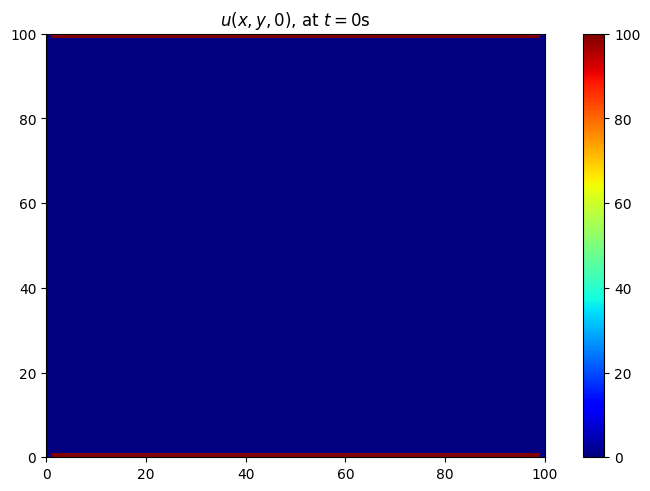

In [5]:
# Initialize solution: u(j, i, n)
u = np.zeros((nx, ny, max_time))

# Initial condition
u_initial = u_initial = 0.0

# Boundary conditions (Dirichlet)
u_right = 0.0
u_left = 0.0
u_bottom = 100.0
u_top = 100.0

# Set the initial condition
u[:, :, 0] = u_initial

# Set the boundary conditions
u[:, (nx-1):, :] = u_right
u[:, :1, :] = u_left
u[:1, 1:(nx-1), :] = u_bottom
u[(ny-1):, 1:(nx-1), :] = u_top

# Visualize domain at t=0
fig, ax = plt.subplots(layout='constrained')
ax.set_title(fr"$u(x, y, {0})$, at $t={0}$s")
hm = ax.pcolormesh(u[:, :, 0], shading='auto', cmap=plt.cm.jet, vmin=u[:, :, 0].min(), vmax=u[:, :, 0].max())
fig.colorbar(mappable=hm, ax=ax)

In [6]:
u = calc_u_fd(u, use_opt=False)

ani = mplanim.FuncAnimation(fig=fig, func=update_u, fargs=(u,), interval=150, frames=max_time, repeat=True)
ani

##### Example 2:
Set top, bottom, left and right BCs to $0.0$ K and the interior with ICs set to $0.0$ K except for a circular region with a temperature of $50.0$ K. The circular region has a radius, $r$, of 2 centered at $(5,5)$ within the domain.

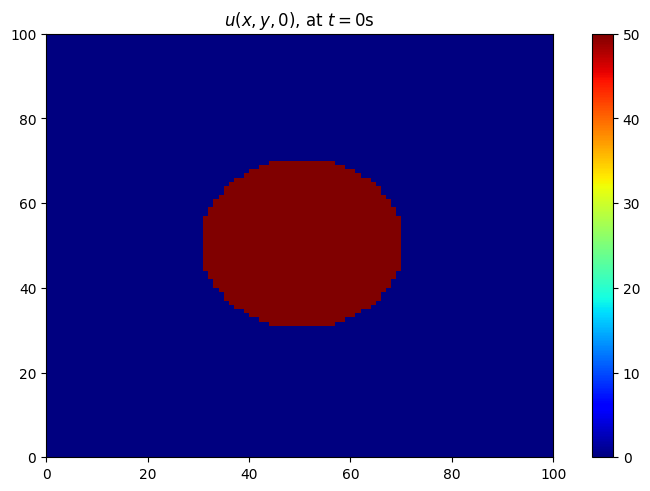

In [8]:
# Initialize solution: u(j, i, n)
u = np.zeros((nx, ny, max_time))

# Initial condition
u_initial = u_initial = 0.0

# Boundary conditions (Dirichlet)
u_right = 0.0
u_left = 0.0
u_bottom = 0.0
u_top = 0.0

# Set the initial condition
u[:, :, 0] = u_initial

# Set initial conditions for inner circle
r, cx, cy = 20, 50, 50
for i in range(nx):
    for j in range(ny):
        # Calculate distance of point from centre
        p = (i*delta_x - cx)**2 + (j*delta_y - cy)**2
        # Assign if point < r
        if p < r**2:
            u[i, j, 0] = 50.0

# Visualize domain at t=0
fig, ax = plt.subplots(layout='constrained')
ax.set_title(fr"$u(x, y, {0})$, at $t={0}$s")
hm = ax.pcolormesh(u[:, :, 0], shading='auto', cmap=plt.cm.jet, vmin=u[:, :, 0].min(), vmax=u[:, :, 0].max())
fig.colorbar(mappable=hm, ax=ax)

In [9]:
u = calc_u_fd(u, use_opt=False)

ani = mplanim.FuncAnimation(fig=fig, func=update_u, fargs=(u,), interval=150, frames=max_time, repeat=True)
ani